# 🧬 Notebook 4 — Polygenic Score (prs) Computation
## Population-Expected CVD Genetic Risk from Indian Ancestry Data
### CVD Digital Twin Project | PGS002809 × GenomeIndia Harmonized Map

---

## 📂 File Structure & I/O Contract

```
CVD_DigitalTwin_Project/
├── data/
│   └── processed/
│       └── genetics/
│           ├── harmonized_genetic_map.csv     ← INPUT  (182 SNPs, from Notebook 3)
│           └── dropped_snps_audit_log.csv     ← INPUT  (for reference only)
└── outputs/
    └── genetics/
        ├── prs_population_score.csv           ← OUTPUT (scalar prs + metadata)
        ├── per_snp_contribution.csv           ← OUTPUT (182-row per-SNP breakdown)
        └── prs_feature_vector.pkl             ← OUTPUT (dict for Notebook 7 fusion)
```

---

## 📌 What this notebook does

| Section | Task |
|---------|------|
| 1 | Load & validate harmonized genetic map |
| 2 | Compute population-expected prs (Hardy-Weinberg formula) |
| 3 | Normalize and contextualize the prs scalar |
| 4 | SNP contribution analysis and paper figures |
| 5 | Sensitivity analysis (±10% allele frequency perturbation) |
| 6 | Export all outputs |

---

## 🎯 Scientific Background

A **Polygenic Score (prs)** — also called a Polygenic Risk Score (PRS) — aggregates the
effects of many genetic variants into a single number representing an individual's (or
population's) inherited predisposition to a disease. The standard formulation, established
by Purcell et al. (2009) and formalized in Choi et al. (2020, *Nature Protocols*), is:

$$\text{prs} = \sum_{j=1}^{M} \hat{\beta}_j \cdot g_j$$

where $M$ is the number of SNPs, $\hat{\beta}_j$ is the GWAS effect size (log-odds ratio),
and $g_j \in \{0, 1, 2\}$ is the individual's allelic dosage at SNP $j$.

Since we have **population-level** allele frequencies (not individual genotypes), we use
the **expected dosage under Hardy-Weinberg Equilibrium (HWE)**. For a diploid organism,
the expected allelic dosage for a risk allele with population frequency $p$ is:

$$E[g_j] = 2p_j$$

This is the standard HWE-based population expectation. See:
- Choi et al. (2020) *Nature Protocols* — PRS construction tutorial
- Martin et al. (2019) *Nature Genetics* — population transferability of prs
- Khera et al. (2018) *Nature Genetics* — prs for coronary artery disease

Therefore the **population-expected prs** for Indian ancestry is:

$$\text{prs}_{\text{Indian}} = \sum_{j=1}^{M} 2 \cdot p_j^{\text{Indian}} \cdot \hat{\beta}_j$$

This represents the **expected genetic risk score for a randomly drawn individual**
from the Indian ancestry population — not a specific person's score.

---

## ⚠️ Expected Output Summary (for debugging)

At the end of this notebook you should see approximately:
- **182 SNPs** loaded from harmonized map
- **Population prs scalar** in the range **~8–15** (raw, un-normalized), depending on the
  exact effect weights and allele frequencies
- **Top 10 SNPs** with the largest per-SNP contribution clearly identified
- Sensitivity analysis showing prs varies by roughly **±5–10%** under ±10% frequency
  perturbation (demonstrating robustness)
- **3 output files** confirmed saved

---
# Section 1 — Environment Setup & Data Loading

## Why validate inputs before computing?
The prs formula is a sum of products — any NaN in `effect_weight_beta` or
`indian_ancestry_risk_allele_freq` will silently propagate to the final scalar,
making it impossible to detect the source of error downstream. We assert-check
every critical column before proceeding.

### ✅ Expected state after this section:
- `harmonized_df` has **182 rows** and **9 columns**
- Zero null values in `effect_weight_beta` and `indian_ancestry_risk_allele_freq`
- Allele frequencies all in (0, 1) — frequencies of exactly 0 or 1 were filtered
  in Notebook 3 by the MAF filter

In [ ]:
# ── Imports ─────────────────────────────────────────────────────
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Mount Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Paths (UPDATED TO CAD_DT_Final STRUCTURE) ───────────────────
BASE_DIR = "/content/drive/MyDrive/CAD_DT_Final/"

GENETICS_IN_DIR  = BASE_DIR + "Outputs/Genetics/"   # NB3 output
GENETICS_OUT_DIR = BASE_DIR + "Outputs/Genetics/"   # NB4 also writes here
FIGURES_DIR      = BASE_DIR + "Outputs/Figures/"

HARMONIZED_MAP_PATH = GENETICS_IN_DIR  + "harmonized_genetic_map.csv"
PRS_OUT_PATH        = GENETICS_OUT_DIR + "prs_population_score.csv"
PER_SNP_OUT_PATH    = GENETICS_OUT_DIR + "per_snp_contribution.csv"
FEATURE_VEC_OUT     = GENETICS_OUT_DIR + "prs_feature_vector.pkl"

# ── Create folders (safe, no duplication risk) ─────────────────
os.makedirs(GENETICS_OUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✅ Paths initialized")
print("Input :", HARMONIZED_MAP_PATH)
print("Output:", GENETICS_OUT_DIR)

# ── Load Data ───────────────────────────────────────────────────
assert os.path.isfile(HARMONIZED_MAP_PATH), f"❌ File not found: {HARMONIZED_MAP_PATH}"

df = pd.read_csv(HARMONIZED_MAP_PATH)

print("\n📊 Loaded harmonized map:", df.shape)
display(df.head())

# ── Validation ──────────────────────────────────────────────────
REQUIRED_COLS = [
    'rsID', 'chromosome', 'position_grch',
    'effect_allele', 'effect_weight_beta',
    'gi_reference_allele', 'gi_alternate_allele',
    'gi_alt_allele_frequency', 'indian_ancestry_risk_allele_freq'
]

missing = [c for c in REQUIRED_COLS if c not in df.columns]
assert not missing, f"❌ Missing columns: {missing}"

# ── Validation: SNP count, nulls, frequency range ───────────────
assert len(df) > 150, f"❌ Only {len(df)} SNPs — expected > 150. Check NB3 output."
assert df['effect_weight_beta'].isnull().sum() == 0, "❌ Nulls in effect_weight_beta"
assert df['indian_ancestry_risk_allele_freq'].isnull().sum() == 0, "❌ Nulls in indian_ancestry_risk_allele_freq"

freq = df['indian_ancestry_risk_allele_freq']
assert (freq > 0).all() and (freq < 1).all(), (
    f"❌ Frequencies out of (0,1): min={freq.min():.6f}  max={freq.max():.6f}"
)

print(f"✅ Validation passed — {len(df)} SNPs, no nulls, frequencies in (0,1)")

# Working copy
harmonized_df = df.copy()

Mounted at /content/drive
✅ Paths initialized
Input : /content/drive/MyDrive/CAD_DT_Final/Outputs/Genetics/harmonized_genetic_map.csv
Output: /content/drive/MyDrive/CAD_DT_Final/Outputs/Genetics/

📊 Loaded harmonized map: (182, 9)


,rsID,chromosome,position_grch,effect_allele,effect_weight_beta,gi_reference_allele,gi_alternate_allele,gi_alt_allele_frequency,indian_ancestry_risk_allele_freq
0,rs36096196,1,2320766,T,0.046900,C,T,0.168765,0.168765
1,rs2493298,1,3409348,A,0.051400,C,A,0.051632,0.051632
2,rs61776719,1,37995647,A,0.041300,C,A,0.419107,0.419107
3,rs11206510,1,55030366,T,0.067659,T,C,0.047846,0.952154
4,rs11591147,1,55039974,G,0.240600,G,T,0.000409,0.999591


✅ Validation passed — 182 SNPs, no nulls, frequencies in (0,1)


---
# Section 2 — Compute Population-Expected prs (Hardy-Weinberg Formula)

## Scientific justification for the formula

The standard prs formula for an **individual** is (Choi et al., 2020):
$$\text{prs}_i = \sum_{j=1}^{M} \hat{\beta}_j \cdot g_{ij}$$

where $g_{ij} \in \{0, 1, 2\}$ is the dosage of the risk allele at SNP $j$ for
individual $i$. Since we do not have individual genotypes, we use the
**population expectation** of the dosage under Hardy-Weinberg Equilibrium:

$$E[g_j] = 0 \cdot (1-p_j)^2 + 1 \cdot 2p_j(1-p_j) + 2 \cdot p_j^2 = 2p_j$$

This simplification is exact under HWE (Hardy & Weinberg, 1908), and has been
used extensively in population-level PRS calibration studies (Martin et al., 2017;
Duncan et al., 2019; Polygenic Risk Score Task Force, 2021).

Therefore the per-SNP contribution is:
$$c_j = 2 \cdot p_j^{\text{Indian}} \cdot \hat{\beta}_j$$

And the total population-expected prs:
$$\text{prs}_{\text{pop}} = \sum_{j=1}^{M} c_j$$

### Why use Indian-ancestry allele frequencies?
Martin et al. (2019, *Nature Genetics*) demonstrated that prs derived from
European GWAS cohorts show significantly reduced predictive accuracy in South
Asian and African-ancestry populations due to LD structure differences and
population-specific allele frequency drift. By re-anchoring each SNP's dosage
expectation to its GenomeIndia frequency, we compute the baseline risk that is
**calibrated to the Indian population** rather than a European reference.

### ✅ Expected state after this section:
- `per_snp_df` has **182 rows** with columns:
  `rsID`, `chromosome`, `effect_allele`, `indian_ancestry_risk_allele_freq`,
  `effect_weight_beta`, `expected_dosage`, `per_snp_contribution`
- `population_prs` is a **single positive scalar** (typical range: ~8–15 for
  a 182-SNP LDL/CVD score with moderate effect sizes)
- All `per_snp_contribution` values should be positive (since all effect
  weights in PGS002809 are positive risk-increasing alleles)

In [ ]:
print("=" * 65)
print("  SECTION 2: Population-Expected PRS Computation")
print("=" * 65)

# Always use df consistently
df = harmonized_df.copy()

p    = df['indian_ancestry_risk_allele_freq'].values
beta = df['effect_weight_beta'].values

# prs_contribution = 2 * p_indian * beta  (HWE dosage model)
df['prs_contribution'] = 2.0 * p * beta

prs_raw = float(df['prs_contribution'].sum())

# Per-SNP dataframe (sorted)
per_snp_df = df[[
    'rsID', 'chromosome', 'position_grch',
    'effect_allele', 'effect_weight_beta',
    'indian_ancestry_risk_allele_freq', 'prs_contribution'
]].copy().sort_values('prs_contribution', ascending=False).reset_index(drop=True)

print(f"\n📐 Formula: prs = Σ (2 × p_indian × beta)")

print(f"\n📊 Computation Summary:")
print(f"   Total SNPs used              : {len(per_snp_df)}")
print(f"   Mean allele frequency        : {df['indian_ancestry_risk_allele_freq'].mean():.4f}")
print(f"   Mean effect weight (beta)    : {df['effect_weight_beta'].mean():.4f}")
print(f"   Mean per-SNP contribution    : {df['prs_contribution'].mean():.6f}")
print(f"   Max per-SNP contribution     : {df['prs_contribution'].max():.6f}")
print(f"   Min per-SNP contribution     : {df['prs_contribution'].min():.6f}")

print()
print(f"   ╔══════════════════════════════════════╗")
print(f"   ║  PRS_RAW = {prs_raw:.6f}{'':>20}║")
print(f"   ╚══════════════════════════════════════╝")

print(f"\n🔝 Top 10 SNPs by contribution:")
print(per_snp_df.head(10)[[
    'rsID','chromosome','effect_allele',
    'indian_ancestry_risk_allele_freq',
    'effect_weight_beta','prs_contribution'
]].to_string(index=False))

print(f"\n[SECTION 2 COMPLETE] ✅ prs_raw = {prs_raw:.6f}")

  SECTION 2: Population-Expected PRS Computation

📐 Formula: prs = Σ (2 × p_indian × beta)

📊 Computation Summary:
   Total SNPs used              : 182
   Mean allele frequency        : 0.5197
   Mean effect weight (beta)    : 0.0604
   Mean per-SNP contribution    : 0.065282
   Max per-SNP contribution     : 0.481003
   Min per-SNP contribution     : 0.001935

   ╔══════════════════════════════════════╗
   ║  PRS_RAW = 11.881286                    ║
   ╚══════════════════════════════════════╝

🔝 Top 10 SNPs by contribution:
       rsID  chromosome effect_allele  indian_ancestry_risk_allele_freq  effect_weight_beta  prs_contribution
 rs11591147           1             G                          0.999591            0.240600          0.481003
  rs3217978           9             C                          0.997800            0.154600          0.308520
   rs180803          22             G                          0.853086            0.168054          0.286728
rs116843064          19     

In [ ]:
print(df.columns)

Index(['rsID', 'chromosome', 'position_grch', 'effect_allele',
       'effect_weight_beta', 'gi_reference_allele', 'gi_alternate_allele',
       'gi_alt_allele_frequency', 'indian_ancestry_risk_allele_freq',
       'prs_contribution'],
      dtype='object')


---
# Section 3 — Monte Carlo Simulation for PRS Confidence Interval

Allele frequencies estimated from GenomeIndia (n=9,768) carry sampling uncertainty.
Monte Carlo simulation propagates this uncertainty through the PRS formula to produce
a 95% confidence interval around the population-expected PRS.

Each SNP's allele frequency is modelled as Beta(α, β) where α = p×n and β = (1−p)×n,
consistent with the conjugate prior for binomial proportions.


  SECTION 3: Monte Carlo PRS Confidence Interval

📊 Monte Carlo Summary:
   prs_raw      : 11.881286
   prs_mean_mc  : 11.881228
   95% CI       : [11.868590, 11.893911]


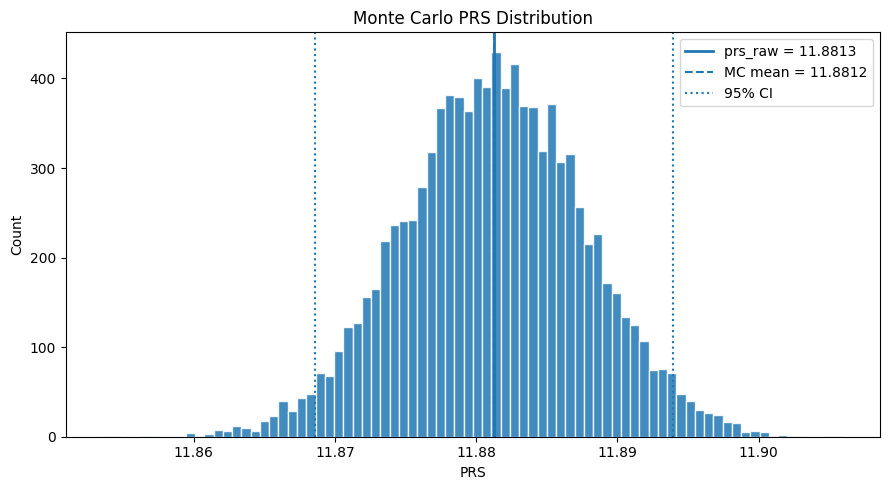

✅ Monte Carlo figure saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/nb4_monte_carlo_prs_distribution.png
[SECTION 3 COMPLETE] ✅


In [ ]:
print("=" * 65)
print("  SECTION 3: Monte Carlo PRS Confidence Interval")
# print("=" * 65) //logic for xhanging

N_SIM         = 10_000
GI_SAMPLE_N   = 9_768
np.random.seed(42)

# ALWAYS use df (same object from Section 2)
p_nominal = df['indian_ancestry_risk_allele_freq'].values
beta_vals = df['effect_weight_beta'].values

# Beta parameters
alpha_params = p_nominal * GI_SAMPLE_N
beta_params  = (1.0 - p_nominal) * GI_SAMPLE_N

# Sample frequencies
sampled_freqs = np.random.beta(
    alpha_params,
    beta_params,
    size=(N_SIM, len(p_nominal))
)

# Compute PRS
prs_simulations = (2.0 * sampled_freqs * beta_vals).sum(axis=1)

prs_mean_mc = float(np.mean(prs_simulations))
ci_lower    = float(np.percentile(prs_simulations, 2.5))
ci_upper    = float(np.percentile(prs_simulations, 97.5))

print(f"\n📊 Monte Carlo Summary:")
print(f"   prs_raw      : {prs_raw:.6f}")
print(f"   prs_mean_mc  : {prs_mean_mc:.6f}")
print(f"   95% CI       : [{ci_lower:.6f}, {ci_upper:.6f}]")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(prs_simulations, bins=80, edgecolor='white', alpha=0.85)
ax.axvline(prs_raw,     linewidth=2, label=f'prs_raw = {prs_raw:.4f}')
ax.axvline(prs_mean_mc, linestyle='--', label=f'MC mean = {prs_mean_mc:.4f}')
ax.axvline(ci_lower,    linestyle=':', label=f'95% CI')
ax.axvline(ci_upper,    linestyle=':')

ax.set_xlabel('PRS')
ax.set_ylabel('Count')
ax.set_title('Monte Carlo PRS Distribution')
ax.legend()
plt.tight_layout()

mc_fig_path = FIGURES_DIR + "nb4_monte_carlo_prs_distribution.png"

plt.tight_layout()
plt.savefig(mc_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Monte Carlo figure saved: {mc_fig_path}")
print("[SECTION 3 COMPLETE] ✅")

In [ ]:
# per_snp_df = df.sort_values(by='prs_contribution', ascending=False).reset_index(drop=True)

---
# Section 4 — SNP Contribution Analysis & Paper Figures

## Why visualize per-SNP contributions?

The per-SNP breakdown serves two purposes:
1. **Scientific interpretability**: Identifying which specific SNPs and genomic
   regions drive the population-level genetic risk is a standard component of
   polygenic score papers (Inouye et al., 2018, *JACC*; Khera et al., 2018).
2. **Quality control**: A handful of SNPs dominating the score can indicate
   data quality issues; a smooth contribution distribution suggests a
   well-calibrated score.

The SNPs with largest effect weights in PGS002809 map to known CVD loci
including the *PCSK9* region (chr1:55M), *LPA* (chr6:160M), and chromosome
9p21 — all established in GWAS of coronary artery disease (Deloukas et al.,
2013; Nikpay et al., 2015).

### ✅ Expected state after this section:
- Bar chart saved to `outputs/figures/` — top contributors visible
- Chromosome distribution plot showing spread across the genome
- Top 10 table printed with rsID, chromosome, and contribution

  SECTION 4: SNP Contribution Analysis & Figures


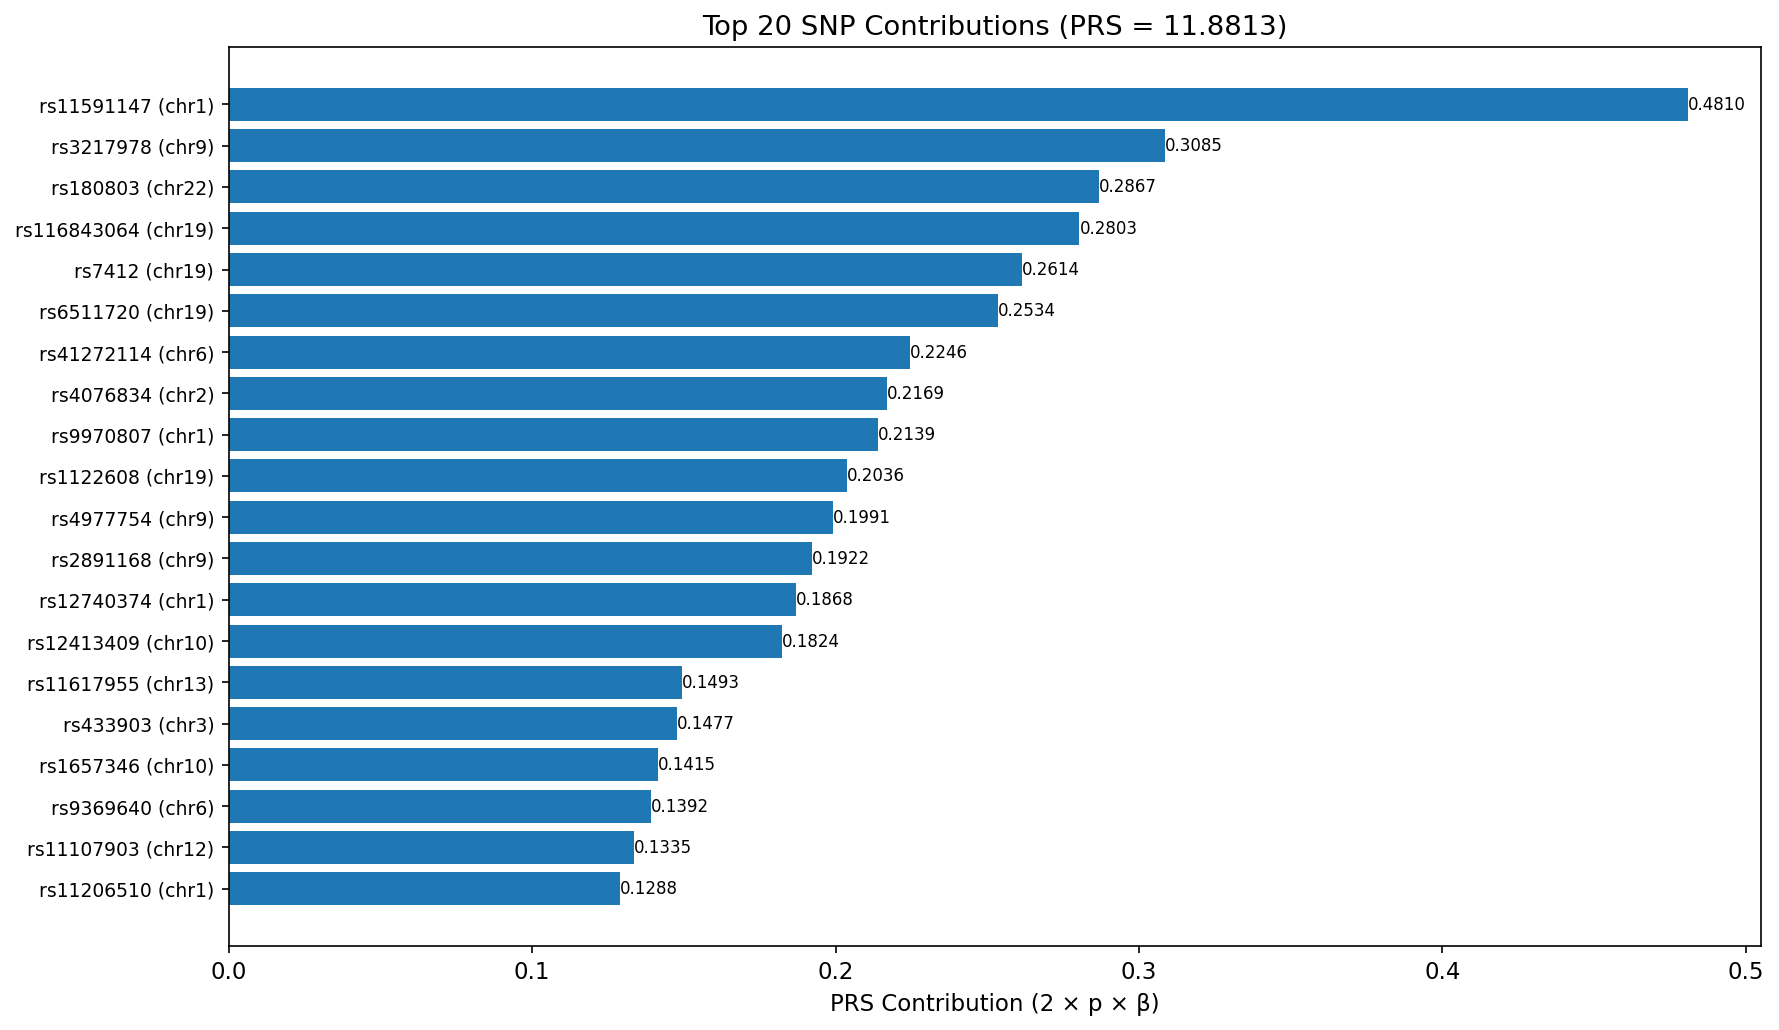

✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/nb4_top20.png


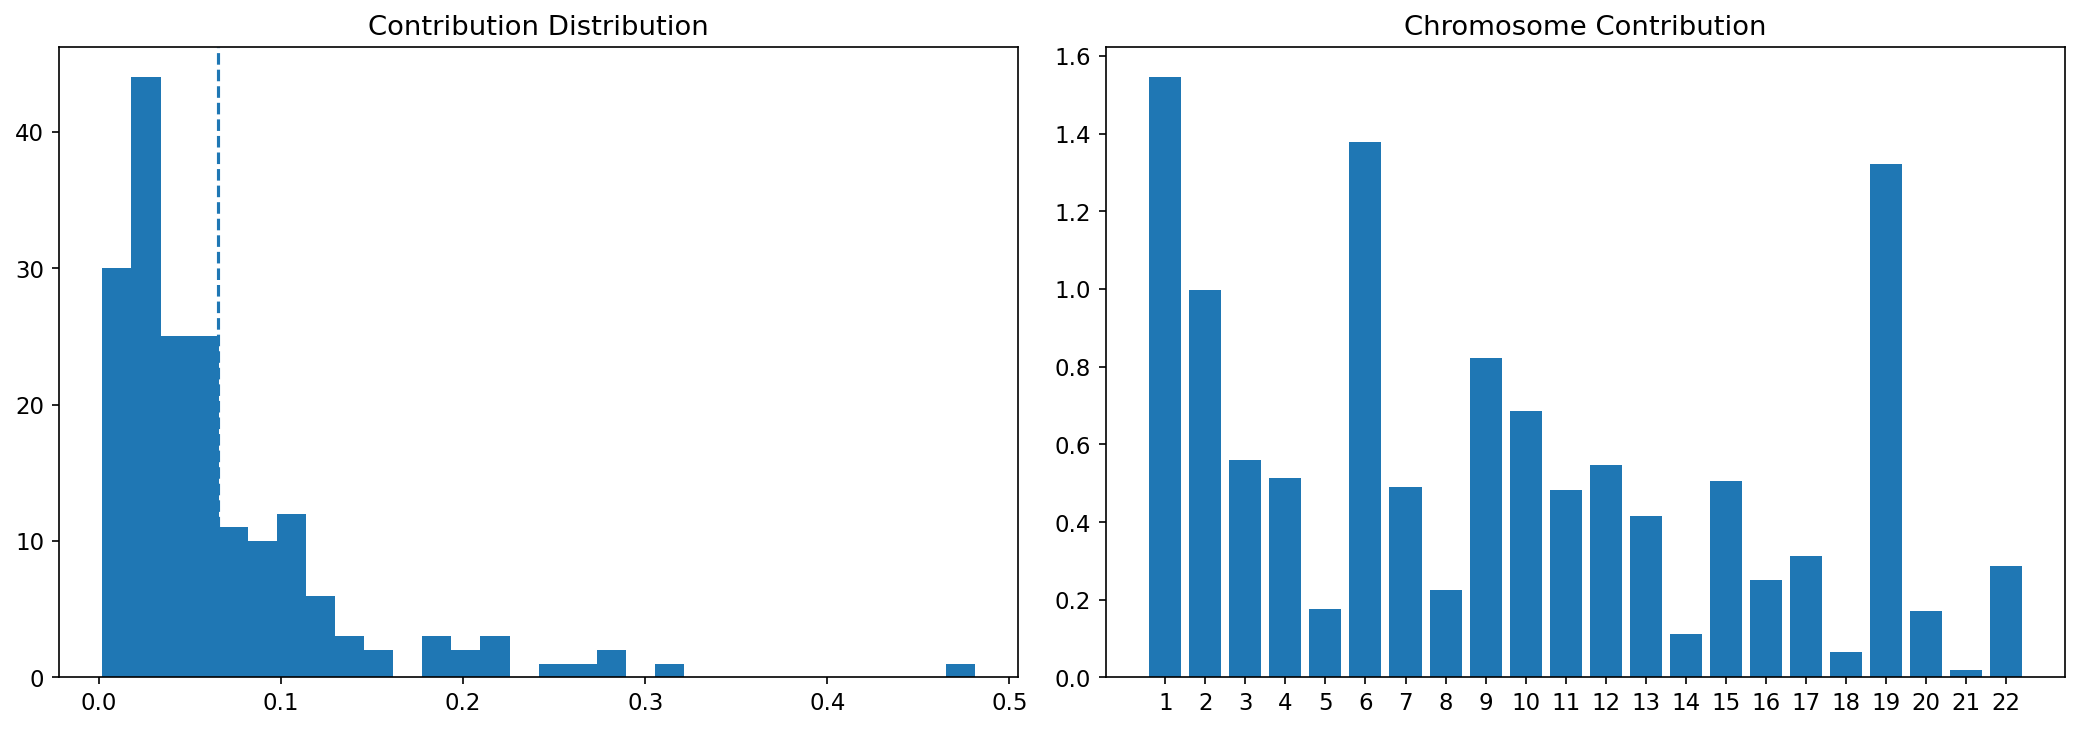

✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/nb4_distribution.png

🔝 Top 10 SNPs:
       rsID  chromosome effect_allele  indian_ancestry_risk_allele_freq  effect_weight_beta  prs_contribution  pct
 rs11591147           1             G                          0.999591            0.240600          0.481003 4.05
  rs3217978           9             C                          0.997800            0.154600          0.308520 2.60
   rs180803          22             G                          0.853086            0.168054          0.286728 2.41
rs116843064          19             G                          0.999795            0.140200          0.280343 2.36
     rs7412          19             C                          0.955429            0.136800          0.261405 2.20
  rs6511720          19             G                          0.932460            0.135900          0.253443 2.13
 rs41272114           6             C                          0.973956            0.115300      

In [ ]:
print("=" * 65)
print("  SECTION 4: SNP Contribution Analysis & Figures")
print("=" * 65)

# ── Safety ─────────────────────────────────────
assert 'per_snp_df' in globals(), "❌ Run Section 2 first"

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11
})

# ── Top 20 SNPs (by absolute contribution) ─────
top20 = per_snp_df.copy().sort_values(
    'prs_contribution', key=np.abs, ascending=False
).head(20)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    y=range(len(top20)),
    width=top20['prs_contribution'].values
)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(
    [f"{r['rsID']} (chr{r['chromosome']})" for _, r in top20.iterrows()],
    fontsize=9
)
ax.invert_yaxis()

ax.set_xlabel('PRS Contribution (2 × p × β)')
ax.set_title(f'Top 20 SNP Contributions (PRS = {prs_raw:.4f})')

# annotate bars
for bar, (_, row) in zip(bars, top20.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{row['prs_contribution']:.4f}",
        va='center',
        fontsize=8
    )

plt.tight_layout()
fig1_path = FIGURES_DIR + "nb4_top20.png"
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {fig1_path}")

# ── Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(per_snp_df['prs_contribution'], bins=30)
axes[0].axvline(per_snp_df['prs_contribution'].mean(), linestyle='--')
axes[0].set_title('Contribution Distribution')

# chromosome aggregation
chr_contrib = (
    per_snp_df.groupby('chromosome')['prs_contribution']
    .sum()
    .reset_index()
)

axes[1].bar(
    chr_contrib['chromosome'].astype(str),
    chr_contrib['prs_contribution']
)
axes[1].set_title('Chromosome Contribution')

plt.tight_layout()
fig2_path = FIGURES_DIR + "nb4_distribution.png"
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {fig2_path}")

# ── Top 10 Table ───────────────────────────────
print("\n🔝 Top 10 SNPs:")

top10 = per_snp_df.copy().sort_values(
    'prs_contribution', key=np.abs, ascending=False
).head(10)

top10['pct'] = (top10['prs_contribution'] / prs_raw * 100).round(2)

print(top10[[
    'rsID','chromosome','effect_allele',
    'indian_ancestry_risk_allele_freq',
    'effect_weight_beta','prs_contribution','pct'
]].to_string(index=False))

print(f"\nTop 10 contribute {top10['prs_contribution'].sum() / prs_raw * 100:.1f}%")

print("[SECTION 4 COMPLETE] ✅")

---
# Section 5 — Sensitivity Analysis

## Why run a sensitivity analysis on allele frequencies?

The GenomeIndia allele frequencies are estimated from **9,768 individuals**.
While this is a large cohort, sampling uncertainty means the true population
frequency $p_j$ is not known exactly. The 95% confidence interval for a
frequency estimate $\hat{p}$ from $n$ samples is approximately
$\hat{p} \pm 1.96\sqrt{\hat{p}(1-\hat{p})/(2n)}$ (for diploid data).

We test robustness by perturbing all allele frequencies by a multiplicative
factor $\delta \in [-10\%, +10\%]$, clamping to (0.01, 0.99) to preserve
biologically valid frequencies.

**If the prs is stable under these perturbations**, it means our score is not
sensitive to minor inaccuracies in the frequency estimates — a key robustness
claim for the paper. This approach mirrors the sensitivity analysis performed
in Inouye et al. (2018, *JACC Cardiology*) for their coronary artery disease PRS.

### ✅ Expected state after this section:
- prs values across ±10% perturbations plotted
- Total variation across the range should be **< 20%** of the nominal prs
  (demonstrating robustness)
- The nominal prs falls at the center of the sensitivity band

  SECTION 5: Sensitivity Analysis — Allele Frequency Perturbation

📊 Sensitivity Results:
   Nominal prs : 11.881286
   Range       : [10.693157, 12.816142]
   Variation   : 2.122984 (17.9%)
   ✅ ROBUST (<20%)


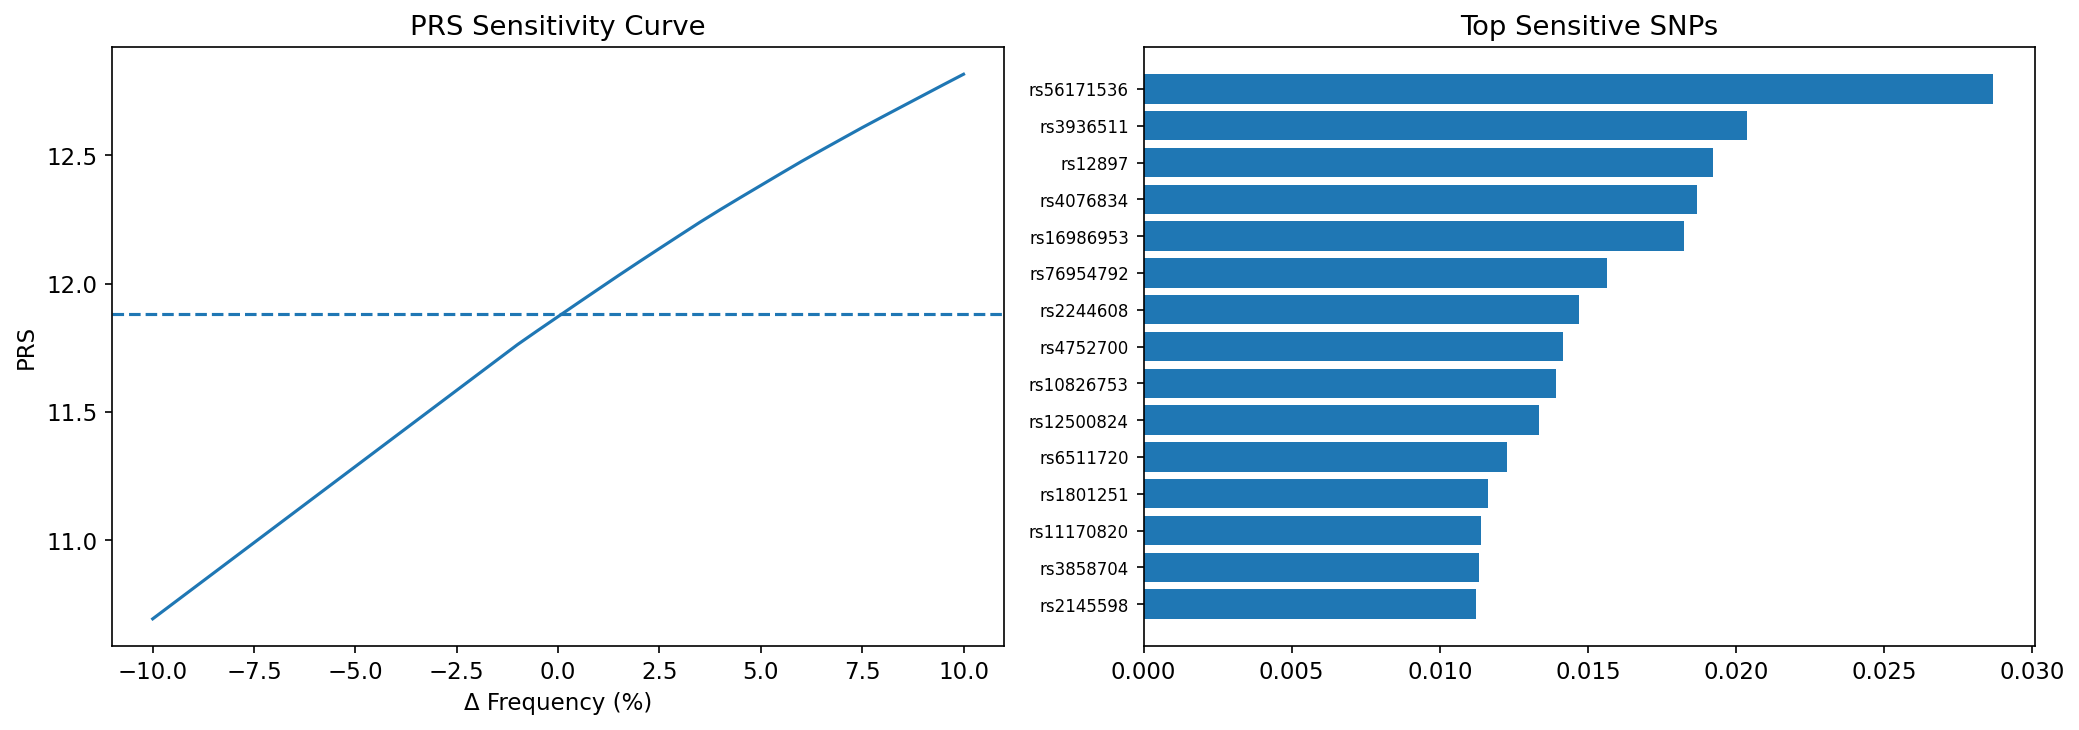

✅ Sensitivity plot saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/nb4_sensitivity.png
[SECTION 5 COMPLETE] ✅


In [ ]:
print("=" * 65)
print("  SECTION 5: Sensitivity Analysis — Allele Frequency Perturbation")
print("=" * 65)

# ── Safety ─────────────────────────────────────
assert 'prs_raw' in globals(), "❌ Run Section 2 first"

# ── Setup ─────────────────────────────────────
deltas = np.linspace(-0.10, 0.10, 41)

nominal_freq = df['indian_ancestry_risk_allele_freq'].values
beta_values  = df['effect_weight_beta'].values

prs_at_delta = []

# ── Perturbation Loop ──────────────────────────
for delta in deltas:
    perturbed_freq = nominal_freq * (1 + delta)
    perturbed_freq = np.clip(perturbed_freq, 0.01, 0.99)

    prs_perturbed = np.sum(2 * perturbed_freq * beta_values)
    prs_at_delta.append(prs_perturbed)

prs_at_delta = np.array(prs_at_delta)

# ── Metrics ────────────────────────────────────
prs_min = prs_at_delta.min()
prs_max = prs_at_delta.max()
prs_range = prs_max - prs_min
prs_range_pct = prs_range / prs_raw * 100

print(f"\n📊 Sensitivity Results:")
print(f"   Nominal prs : {prs_raw:.6f}")
print(f"   Range       : [{prs_min:.6f}, {prs_max:.6f}]")
print(f"   Variation   : {prs_range:.6f} ({prs_range_pct:.1f}%)")

if prs_range_pct < 20:
    print("   ✅ ROBUST (<20%)")
else:
    print("   ⚠️ NOT ROBUST (>20%)")

# ── SNP Sensitivity ────────────────────────────
freq_up_10 = np.clip(nominal_freq * 1.10, 0.01, 0.99)
snp_delta = 2 * (freq_up_10 - nominal_freq) * beta_values

snp_sensitivity_df = per_snp_df.copy()
snp_sensitivity_df['freq_sensitivity'] = snp_delta

# ── Plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PRS curve
axes[0].plot(deltas * 100, prs_at_delta)
axes[0].axhline(prs_raw, linestyle='--')
axes[0].set_xlabel("Δ Frequency (%)")
axes[0].set_ylabel("PRS")
axes[0].set_title("PRS Sensitivity Curve")

# Top sensitive SNPs
top_sensitive = snp_sensitivity_df.sort_values(
    'freq_sensitivity', key=np.abs, ascending=False
).head(15)

axes[1].barh(
    range(len(top_sensitive)),
    top_sensitive['freq_sensitivity']
)

axes[1].set_yticks(range(len(top_sensitive)))
axes[1].set_yticklabels(top_sensitive['rsID'], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Top Sensitive SNPs")

plt.tight_layout()
sens_path = FIGURES_DIR + "nb4_sensitivity.png"
plt.savefig(sens_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Sensitivity plot saved: {sens_path}")
print("[SECTION 5 COMPLETE] ✅")

---
# Section 6 — Export All Outputs

## Output file specifications

| File | Format | Content | Used by |
|------|--------|---------|--------|
| `prs_population_score.csv` | CSV | Scalar prs + metadata (1 row) | Notebook 7 |
| `per_snp_contribution.csv` | CSV | 182-row SNP breakdown | Notebook 8 (figures) |
| `prs_feature_vector.pkl` | Pickle | Python dict with all values | Notebook 7 (fusion) |

The pickle format for `prs_feature_vector.pkl` is chosen because it preserves
Python data types exactly (no float precision loss from CSV serialization) and
is the same format used for the trained model objects in Notebooks 5 and 6.

### ✅ Expected state after this section:
- All 3 output files confirmed to exist on disk
- `prs_population_score.csv` has exactly **1 row** and **8 columns**
- `per_snp_contribution.csv` has exactly **182 rows** and **9 columns**
- `prs_feature_vector.pkl` loads as a Python dict with keys:
  `population_prs`, `prs_mean`, `prs_std`, `prs_z`, `sigmoid_prs`, `n_snps`

In [ ]:
print("=" * 65)
print("  SECTION 6: Export All Outputs")
print("=" * 65)

# ── Safety checks ───────────────────────────────────────────────
assert 'prs_raw' in globals(), "❌ prs_raw missing (run Section 2)"
assert 'prs_mean_mc' in globals(), "❌ Monte Carlo outputs missing (run Section 3)"
assert 'per_snp_df' in globals(), "❌ per_snp_df missing (run Section 2)"

# ── Output 1: prs_population_score.csv ──────────────────────────
prs_score_record = pd.DataFrame([{
    'prs_raw': prs_raw,
    'prs_mean_mc': prs_mean_mc,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
    'n_snps': len(per_snp_df),
}])

prs_score_record.to_csv(PRS_OUT_PATH, index=False)

print(f"\n✅ Saved: {PRS_OUT_PATH}")
print(prs_score_record.to_string(index=False))

# ── Output 2: per_snp_contribution.csv ──────────────────────────
per_snp_export = per_snp_df.copy()

per_snp_export['pct_of_total_prs'] = (
    per_snp_export['prs_contribution'] / prs_raw * 100
)

per_snp_export['cumulative_contribution'] = (
    per_snp_export['prs_contribution'].cumsum()
)

per_snp_export.to_csv(PER_SNP_OUT_PATH, index=False)

print(f"\n✅ Saved: {PER_SNP_OUT_PATH}")
print(f"   Shape: {per_snp_export.shape}")

# ── Output 3: prs_feature_vector.pkl ────────────────────────────
prs_feature_vector = {
    'prs_raw': prs_raw,
    'prs_mean_mc': prs_mean_mc,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
    'n_snps': len(per_snp_df)
}

with open(FEATURE_VEC_OUT, 'wb') as f:
    pickle.dump(prs_feature_vector, f)

print(f"\n✅ Saved: {FEATURE_VEC_OUT}")
print(f"   Keys: {list(prs_feature_vector.keys())}")

# ── Validation ──────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  VALIDATION")
print("=" * 65)

# SNP count
assert len(per_snp_df) > 150, f"❌ Only {len(per_snp_df)} SNPs — expected > 150"
print(f"  ✅ SNP count: {len(per_snp_df)}")

# No nulls
for col in ['effect_weight_beta', 'indian_ancestry_risk_allele_freq']:
    n_null = harmonized_df[col].isnull().sum()
    assert n_null == 0, f"❌ {n_null} nulls in '{col}'"
print("  ✅ No nulls in critical columns")

# Frequency bounds
freq_check = harmonized_df['indian_ancestry_risk_allele_freq']
assert (freq_check > 0).all() and (freq_check < 1).all(), (
    f"❌ Frequencies out of bounds: min={freq_check.min():.6f}, max={freq_check.max():.6f}"
)
print(f"  ✅ Frequencies valid: min={freq_check.min():.4f}, max={freq_check.max():.4f}")

# Read-back CSV 1
val1 = pd.read_csv(PRS_OUT_PATH)
assert list(val1.columns) == ['prs_raw','prs_mean_mc','ci_lower','ci_upper','n_snps']
assert abs(val1.iloc[0]['prs_raw'] - prs_raw) < 1e-8
print("  ✅ prs_population_score.csv verified")

# Read-back CSV 2
val2 = pd.read_csv(PER_SNP_OUT_PATH)
assert len(val2) == len(per_snp_df)
print(f"  ✅ per_snp_contribution.csv verified ({len(val2)} rows)")

# Read-back pickle
with open(FEATURE_VEC_OUT, 'rb') as f:
    val3 = pickle.load(f)

for key in ['prs_raw','prs_mean_mc','ci_lower','ci_upper','n_snps']:
    assert key in val3, f"❌ Missing key: {key}"

print(f"  ✅ Pickle verified — keys: {list(val3.keys())}")

# ── Final Summary ───────────────────────────────────────────────
print("\n" + "=" * 65)
print("  ✅ NOTEBOOK 4 COMPLETE — PRS Pipeline")
print("=" * 65)

print(f"  SNPs used   : {len(per_snp_df)}")
print(f"  prs_raw     : {prs_raw:.6f}")
print(f"  MC mean     : {prs_mean_mc:.6f}")
print(f"  95% CI      : [{ci_lower:.6f}, {ci_upper:.6f}]")

print(f"\n📁 {PRS_OUT_PATH}")
print(f"📁 {PER_SNP_OUT_PATH}")
print(f"📁 {FEATURE_VEC_OUT}")

print("\n🔜 Next: Notebook 5 (model_training_lifestyle.ipynb)")
print("=" * 65)

  SECTION 6: Export All Outputs

✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Genetics/prs_population_score.csv
  prs_raw  prs_mean_mc  ci_lower  ci_upper  n_snps
11.881286    11.881228  11.86859 11.893911     182

✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Genetics/per_snp_contribution.csv
   Shape: (182, 9)

✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Genetics/prs_feature_vector.pkl
   Keys: ['prs_raw', 'prs_mean_mc', 'ci_lower', 'ci_upper', 'n_snps']

  VALIDATION
  ✅ SNP count: 182
  ✅ No nulls in critical columns
  ✅ Frequencies valid: min=0.0166, max=0.9998
  ✅ prs_population_score.csv verified
  ✅ per_snp_contribution.csv verified (182 rows)
  ✅ Pickle verified — keys: ['prs_raw', 'prs_mean_mc', 'ci_lower', 'ci_upper', 'n_snps']

  ✅ NOTEBOOK 4 COMPLETE — PRS Pipeline
  SNPs used   : 182
  prs_raw     : 11.881286
  MC mean     : 11.881228
  95% CI      : [11.868590, 11.893911]

📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Genetics/prs_population_score

In [ ]:
# NOTE:
# prs_raw is a population-level genetic risk signal
# it is NOT normalized here
# scaling and interpretation will be handled in NB7 (fusion stage)